In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset('titanic') 

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

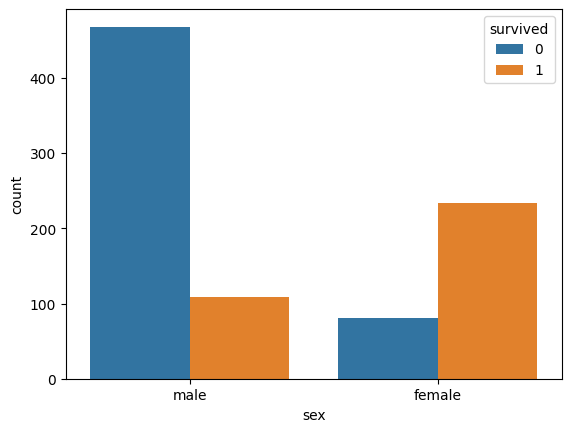

In [4]:
sns.countplot(
    data=df,
    x='sex',
    hue='survived'
)
plt.show()

In [5]:
# take only needed columns
# use imputation technique to fill null values
# encoding (label encoder for sex)
# saperate input X and output y (where y is survived)
# perform train test split
# scaling if needed
# fit the model
# predict
# check the accuracy
# confusion matrix
# import joblib and create .pkl file for model and scaler 


In [6]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
X = df[['pclass','sex','age','sibsp','parch','fare','embarked']]
y = df[['survived']]

In [8]:
X.isna().sum()

pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64

In [9]:
X['age'] = X['age'].fillna(X['age'].median())

In [10]:
X.isna().sum()

pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    2
dtype: int64

In [11]:
X['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [12]:
# from sklearn.preprocessing import OneHotEncoder
# encoder = OneHotEncoder()

In [13]:
X = pd.get_dummies(
    data=X,
    columns=['embarked'],
    dtype=int
)

In [14]:
X

,pclass,sex,age,sibsp,parch,fare,embarked_C,embarked_Q,embarked_S
0,3,male,22.0,1,0,7.2500,0,0,1
1,1,female,38.0,1,0,71.2833,1,0,0
2,3,female,26.0,0,0,7.9250,0,0,1
3,1,female,35.0,1,0,53.1000,0,0,1
4,3,male,35.0,0,0,8.0500,0,0,1
...,...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,0,0,1
887,1,female,19.0,0,0,30.0000,0,0,1
888,3,female,28.0,1,2,23.4500,0,0,1
889,1,male,26.0,0,0,30.0000,1,0,0


In [15]:
sex_encoding = {
    'male': 0,
    'female': 1
}

X['sex'] = X['sex'].map(sex_encoding)

In [16]:
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked_C,embarked_Q,embarked_S
0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,38.0,1,0,71.2833,1,0,0
2,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,3,0,35.0,0,0,8.0500,0,0,1


In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Hyperparameter turing 
# - GridSearch CV
# - Randomize CV

In [27]:
import warnings
warnings.filterwarnings('ignore')

In [19]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [20]:
model = LogisticRegression()

In [28]:
param_grid = {
    'solver': ['saga'],  # 'saga' is required when using l1_ratio / elasticnet
    'penalty': ['elasticnet'],
    'C': [0.01, 0.1, 1.0],
    'l1_ratio': [0.01, 0.1, 1.0]  # Changed from l2_ratio to l1_ratio
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'l1_ratio': [0.01, 0.1, ...], 'penalty': ['elasticnet'], 'solver': ['saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0

In [29]:
grid.cv

5